In [1]:
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns

data = pd.read_csv('RFE_SolCbio3_descs_fps.csv') #import filtered descriptors
data.drop(columns=['smiles'], inplace=True) #remove unwanted columns

In [2]:
from sklearn.model_selection import StratifiedShuffleSplit

# Create a new column 'output' by mapping 'dev' column
data['output'] = data['dev'].map({'NO': 0, 'YES': 1})

# Delete the original 'dev' column
data.drop(columns=['dev'], inplace=True)


X = data.drop('output', axis=1)
y = data['output']


sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_index, test_index in sss.split(X, y):
  X_train, X_test = X.iloc[train_index], X.iloc[test_index]
  y_train, y_test = y.iloc[train_index], y.iloc[test_index]

  # Now you have stratified samples in X_train, X_test, y_train, and y_test

print(f'Training set (80%): {X_train.shape}')
print(f'Test set (20%): {X_test.shape}')
print(f'Accurate predictions of GSE in test set: {100*round(y_test.value_counts()[0]/len(y_test),3)} %')
print(f'Accurate predictions of GSE in training set: {100*round(y_train.value_counts()[0]/len(y_train),3)} %')

Training set (80%): (2192, 75)
Test set (20%): (548, 75)
Accurate predictions of GSE in test set: 65.3 %
Accurate predictions of GSE in training set: 65.4 %


2025-11-19 12:24:23.557105: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-11-19 12:24:24.501846: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/home/esteban_b/miniforge3/lib/python3.12/site-packages/numpy/core/getlimits.py:542: UserWarning: Signature b'\x00\xd0\xcc\xcc\xcc\xcc\xcc\xcc\xfb\xbf\x00\x00\x00\x00\x00\x00' for <class 'numpy.longdouble'> does not match any known type: falling back to type probe function.
This warnings indicates broken support for the dtype!
  machar = _get_machar(dtype)
2025-11-19 12:24:51.575348: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-11-19 12:24:58.349585: E ext

Optimized Neural Network Model Accuracy: 0.7062
Optimized Neural Network Model Sensitivity: 0.5474
Optimized Neural Network Model Specificity: 0.7905


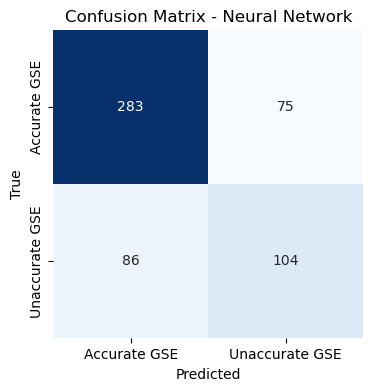

In [3]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import train_test_split
from scikeras.wrappers import KerasClassifier


# Calculate class weights
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = {0: class_weights[0], 1: class_weights[1]}

# Improved model
NN = Sequential([
        Input(shape=(X_train.shape[1],)),
        Dense(64, activation='relu'),
        BatchNormalization(),
        Dropout(0.4),
        Dense(32, activation='relu'),
        BatchNormalization(),
        Dropout(0.3),
        Dense(16, activation='relu'),
        Dense(1, activation='sigmoid')
    ])

# Optimizer with custom learning rate
optimizer = Adam(learning_rate=0.0005)

NN.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])

# Callbacks
early_stop = EarlyStopping(monitor='accuracy', patience=100,
                          restore_best_weights=True, mode='max')
reduce_lr = ReduceLROnPlateau(monitor='accuracy', factor=0.5,
                             patience=20, min_lr=1e-7)


kcv_NN = KerasClassifier(
    model=NN,
    epochs=1000,
    batch_size=32,
    callbacks=[early_stop, reduce_lr],
    class_weight=class_weight_dict,
    verbose=0
  )

# Fit the KerasClassifier model to the training data
kcv_NN.fit(X_train, y_train)

# Evaluate
y_pred_NN_binary = (kcv_NN.predict(X_test) > 0.5).astype(int)

# Calculate the confusion matrix
cm_NN = confusion_matrix(y_test, y_pred_NN_binary)

# Calculate accuracy, sensitivity, and specificity
tn_NN, fp_NN, fn_NN, tp_NN = cm_NN.ravel()

accuracy_NN = (tp_NN + tn_NN) / (tp_NN + tn_NN + fp_NN + fn_NN)
sensitivity_NN = tp_NN / (tp_NN + fn_NN)
specificity_NN = tn_NN / (tn_NN + fp_NN)

# Print the results
print(f'Optimized Neural Network Model Accuracy: {accuracy_NN:.4f}')
print(f'Optimized Neural Network Model Sensitivity: {sensitivity_NN:.4f}')
print(f'Optimized Neural Network Model Specificity: {specificity_NN:.4f}')

# Plot the confusion matrix
plt.figure(figsize=(4, 4))
sns.heatmap(cm_NN, annot=True, fmt='d', cmap='Blues', cbar=False, xticklabels=['Accurate GSE', 'Unaccurate GSE'], yticklabels=['Accurate GSE', 'Unaccurate GSE'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - Neural Network')
plt.show()

In [4]:
!pip uninstall numpy -y
!pip install "numpy<2.0"
import numpy as np
print(np.__version__)

Found existing installation: numpy 1.26.4
Uninstalling numpy-1.26.4:
  Successfully uninstalled numpy-1.26.4
  Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (18.0 MB)
1.26.4


In [5]:
import shap
explainer = shap.KernelExplainer(kcv_NN.predict, X_train)
shap_values = explainer(X_test)

Using 2192 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


  0%|          | 0/548 [00:00<?, ?it/s]

2025-11-19 12:28:02.171143: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 1445404800 exceeds 10% of free system memory.
2025-11-19 12:32:43.990315: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 1445404800 exceeds 10% of free system memory.
2025-11-19 12:36:50.501564: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 1445404800 exceeds 10% of free system memory.
2025-11-19 12:40:47.267556: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 1445404800 exceeds 10% of free system memory.
2025-11-19 12:44:36.641271: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 1445404800 exceeds 10% of free system memory.


In [6]:
features = list(X.columns.values)

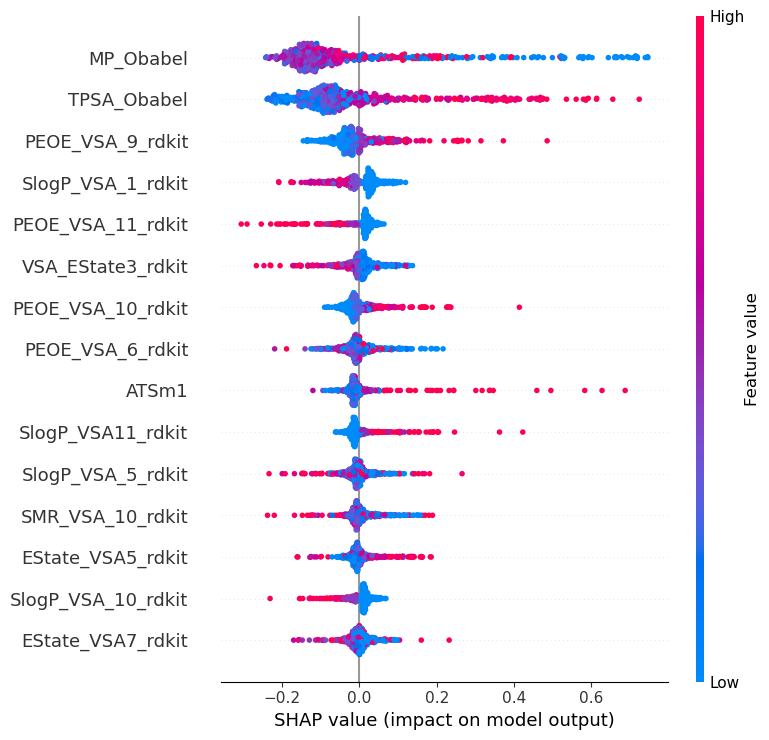

In [16]:
shap.summary_plot(shap_values,X_test,feature_names = features, max_display=15, show = False)
plt.savefig('shap_summary_plot.png', format='png', dpi=300, bbox_inches='tight')
plt.savefig('shap_summary_plot.pdf', format='pdf', dpi=500, bbox_inches='tight')
plt.show()

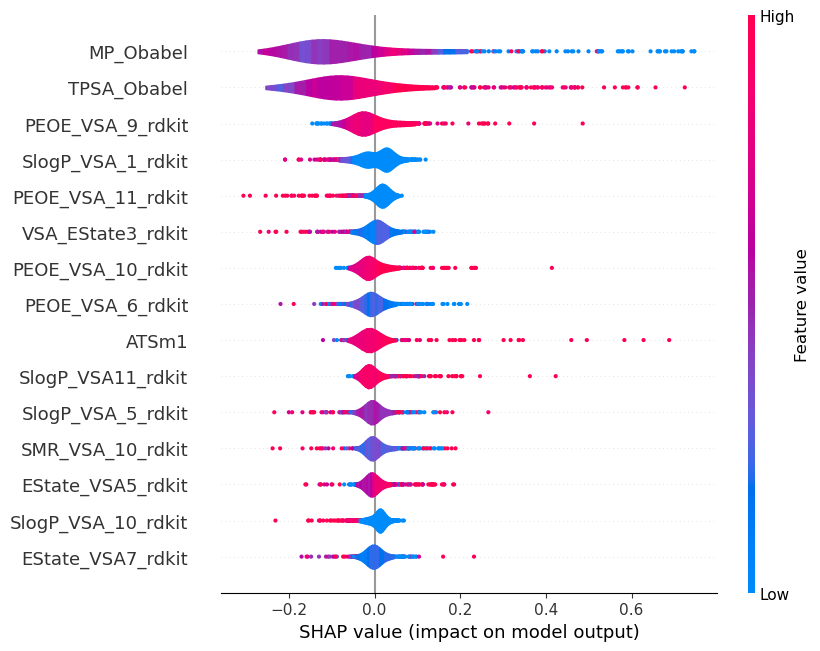

In [8]:
shap.plots.violin(shap_values, features = X_test, feature_names = features, max_display=15)

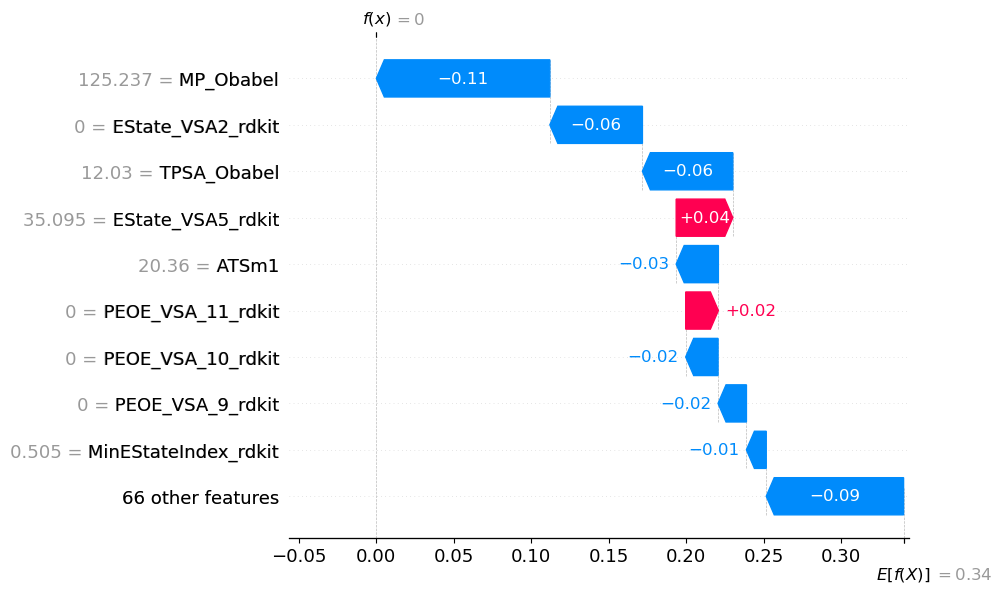

In [17]:
shap.plots.waterfall(shap_values[0], show = False)
plt.savefig('shap_waterfall_plot.png', format='png', dpi=300, bbox_inches='tight')
plt.savefig('shap_waterfall_plot.pdf', format='pdf', dpi=500, bbox_inches='tight')
plt.show()